In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("traffic_accident_dataset_500.xlsx")

In [5]:
df.head()

,Accident_ID,Date,Time,Area,Latitude,Longitude,Road_Condition,Weather,Light_Condition,Traffic_Signal,Speed_Limit,Vehicles_Involved,Casualties,Severity
0,ACC0001,2025-03-21,11:24,Highway Junction,16.519127,80.631981,Under Construction,Foggy,Dawn,Absent,60,1,1,Moderate
1,ACC0002,2025-03-06,23:15,Old City,16.482518,80.635663,Potholes,Cloudy,Daylight,Absent,60,4,1,Moderate
2,ACC0003,2025-06-24,00:02,Downtown,16.506724,80.649358,Potholes,Stormy,Night,Present,80,4,2,Moderate
3,ACC0004,2025-05-08,20:30,Old City,16.482262,80.632869,Dry,Stormy,Night,Absent,50,1,2,Moderate
4,ACC0005,2025-01-28,10:19,River Bridge,16.493495,80.657107,Potholes,Rainy,Dawn,Present,60,1,1,Moderate


In [6]:
print(df.shape)

(500, 14)


In [7]:
print(df.columns)

Index(['Accident_ID', 'Date', 'Time', 'Area', 'Latitude', 'Longitude',
       'Road_Condition', 'Weather', 'Light_Condition', 'Traffic_Signal',
       'Speed_Limit', 'Vehicles_Involved', 'Casualties', 'Severity'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Accident_ID        500 non-null    object 
 1   Date               500 non-null    object 
 2   Time               500 non-null    object 
 3   Area               500 non-null    object 
 4   Latitude           500 non-null    float64
 5   Longitude          500 non-null    float64
 6   Road_Condition     500 non-null    object 
 7   Weather            500 non-null    object 
 8   Light_Condition    500 non-null    object 
 9   Traffic_Signal     500 non-null    object 
 10  Speed_Limit        500 non-null    int64  
 11  Vehicles_Involved  500 non-null    int64  
 12  Casualties         500 non-null    int64  
 13  Severity           500 non-null    object 
dtypes: float64(2), int64(3), object(9)
memory usage: 54.8+ KB


In [9]:
df.describe()

,Latitude,Longitude,Speed_Limit,Vehicles_Involved,Casualties
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.504945,80.641984,51.880000,2.474000,1.858000
std,0.013729,0.011089,17.546548,1.131319,1.156075
min,16.482031,80.617096,30.000000,1.000000,0.000000
25%,16.494385,80.634642,40.000000,1.000000,1.000000
50%,16.503520,80.642975,50.000000,2.000000,2.000000
75%,16.516052,80.649638,60.000000,3.000000,3.000000
max,16.532655,80.662531,80.000000,4.000000,5.000000


In [10]:
df.isnull().sum()

,0
Accident_ID,0
Date,0
Time,0
Area,0
Latitude,0
Longitude,0
Road_Condition,0
Weather,0
Light_Condition,0
Traffic_Signal,0


In [11]:
print(df.duplicated().sum())

0


In [12]:
df = df.drop_duplicates()

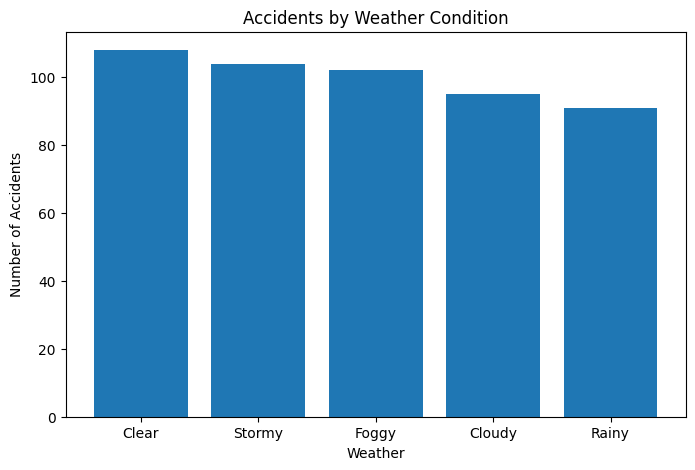

In [13]:
weather = df["Weather"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(weather.index, weather.values)

plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")

plt.show()

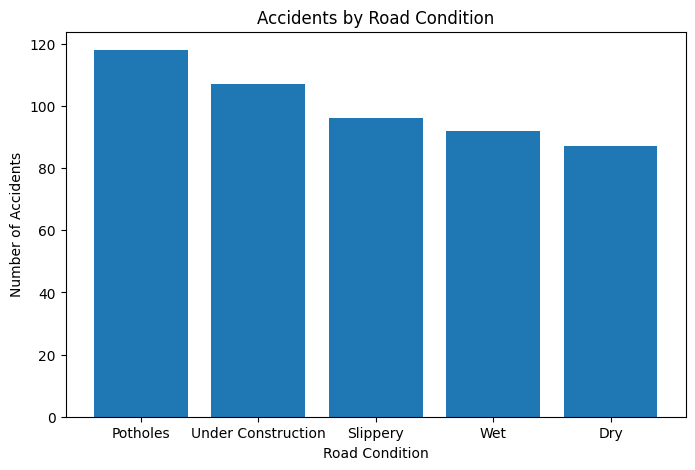

In [14]:
road = df["Road_Condition"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(road.index, road.values)

plt.title("Accidents by Road Condition")
plt.xlabel("Road Condition")
plt.ylabel("Number of Accidents")

plt.show()

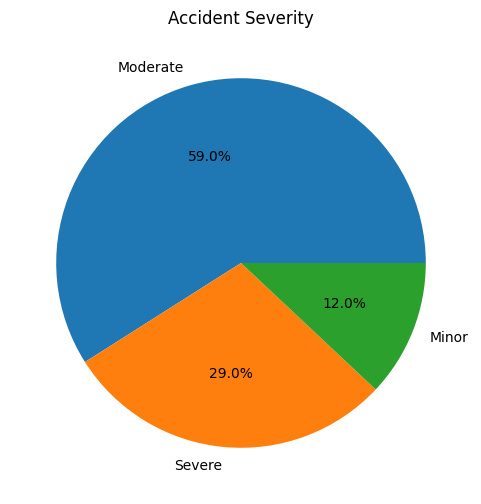

In [15]:
severity = df["Severity"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    severity.values,
    labels=severity.index,
    autopct="%1.1f%%"
)

plt.title("Accident Severity")

plt.show()

In [16]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/tmp/ipykernel_1184/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


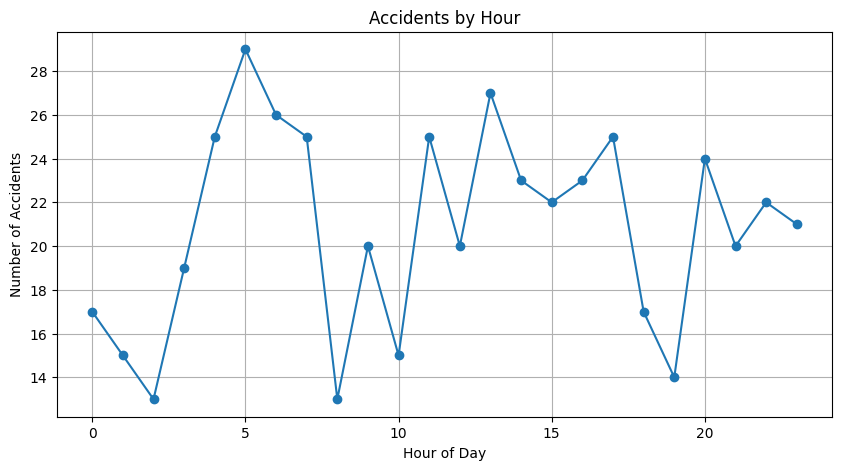

In [17]:
hour = df["Hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(hour.index, hour.values, marker="o")

plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")

plt.grid(True)

plt.show()

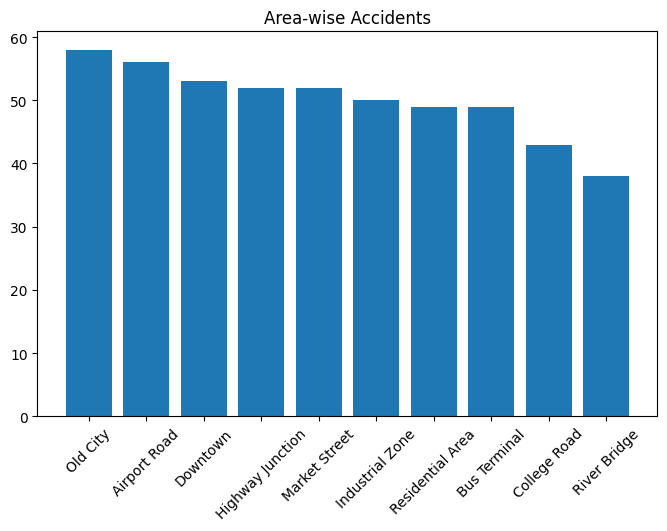

In [18]:
area = df["Area"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(area.index, area.values)

plt.xticks(rotation=45)

plt.title("Area-wise Accidents")

plt.show()

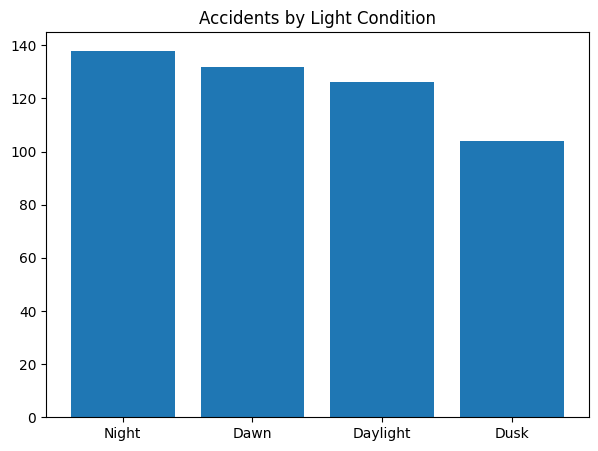

In [19]:
light = df["Light_Condition"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(light.index, light.values)

plt.title("Accidents by Light Condition")

plt.show()

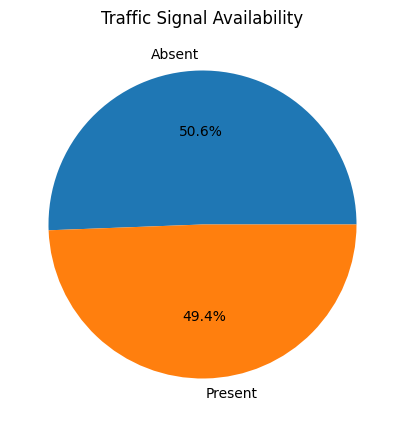

In [20]:
signal = df["Traffic_Signal"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    signal.values,
    labels=signal.index,
    autopct="%1.1f%%"
)

plt.title("Traffic Signal Availability")

plt.show()

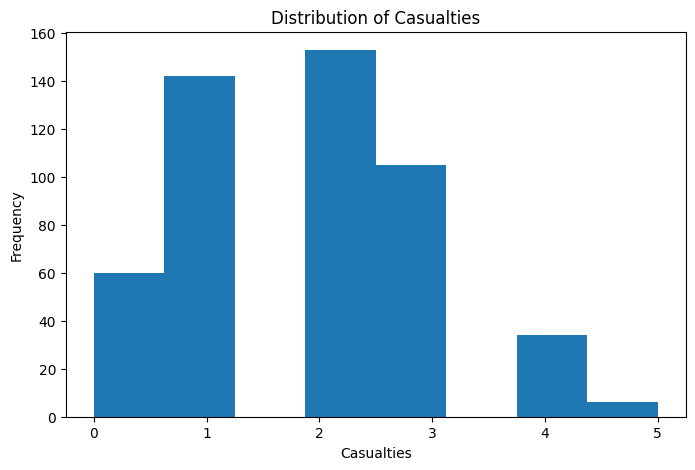

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Casualties"], bins=8)

plt.title("Distribution of Casualties")

plt.xlabel("Casualties")

plt.ylabel("Frequency")

plt.show()

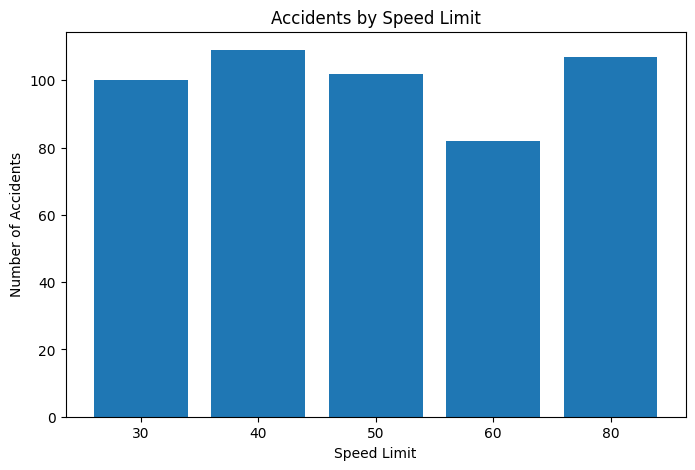

In [22]:
speed = df["Speed_Limit"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(speed.index.astype(str), speed.values)

plt.title("Accidents by Speed Limit")

plt.xlabel("Speed Limit")

plt.ylabel("Number of Accidents")

plt.show()

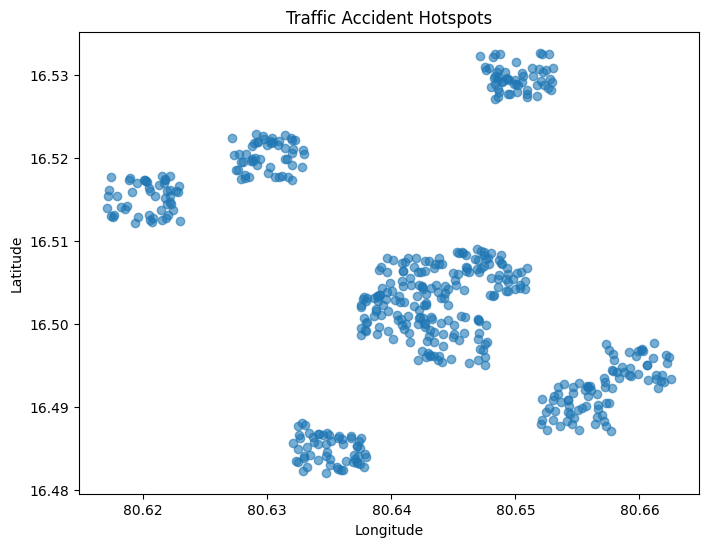

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.6
)

plt.title("Traffic Accident Hotspots")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.show()

In [24]:
top = df["Area"].value_counts().head(10)

print(top)

Area
Old City            58
Airport Road        56
Downtown            53
Highway Junction    52
Market Street       52
Industrial Zone     50
Residential Area    49
Bus Terminal        49
College Road        43
River Bridge        38
Name: count, dtype: int64


In [25]:
print("Total Accidents:", len(df))
print("Average Casualties:", df["Casualties"].mean())
print("Maximum Casualties:", df["Casualties"].max())
print("Average Vehicles Involved:", df["Vehicles_Involved"].mean())

Total Accidents: 500
Average Casualties: 1.858
Maximum Casualties: 5
Average Vehicles Involved: 2.474


In [26]:
print("Traffic Accident Analysis Completed Successfully!")

Traffic Accident Analysis Completed Successfully!
